Feature Extraction (Week 3)


In [2]:
import os
from google.colab import drive

# 1. Force a fresh mount to sync files
drive.mount('/content/drive', force_remount=True)

# 2. Check the path again
BATCH_DIR = '/content/drive/MyDrive/scanned_documents/processed_batches/'

if os.path.exists(BATCH_DIR):
    print(f"✅ SUCCESS! Found {len(os.listdir(BATCH_DIR))} batch files.")
    # Now you can safely run your feature extraction loop
else:
    print("❌ Folder still missing. Check your Drive for 'scanned_documents/processed_batches'")

Mounted at /content/drive
✅ SUCCESS! Found 18 batch files.


In [3]:
import numpy as np
import os
from skimage.feature import local_binary_pattern
from tqdm import tqdm

# Define the verified path from your previous step
BATCH_DIR = '/content/drive/MyDrive/scanned_documents/processed_batches/'
batch_files = sorted([f for f in os.listdir(BATCH_DIR) if f.startswith('X_batch')])

def extract_scanner_fingerprints(image):
    # Ensure image is 2D (remove channel dimension if present)
    img_2d = image.squeeze()

    # 1. FFT (Frequency Domain Feature)
    f_shift = np.fft.fftshift(np.fft.fft2(img_2d))
    # We take the mean magnitude as a simple baseline feature
    fft_feat = np.mean(20 * np.log(np.abs(f_shift) + 1))

    # 2. LBP (Texture Descriptor Feature)
    # Using 8 points and radius of 1 for a standard micro-texture map
    lbp = local_binary_pattern(img_2d, P=8, R=1, method="uniform")
    # Convert the LBP map into a histogram to use as a feature vector
    (hist, _) = np.histogram(lbp.ravel(), bins=np.arange(0, 11), range=(0, 10))
    lbp_feat = hist.astype("float") / hist.sum() # Normalize

    # Combine both into one feature vector
    return np.hstack([fft_feat, lbp_feat])

all_features = []
all_labels = []

print("Extracting fingerprints from all batches...")
for x_file in tqdm(batch_files):
    y_file = x_file.replace('X_batch', 'y_batch')
    X_batch = np.load(os.path.join(BATCH_DIR, x_file))
    y_batch = np.load(os.path.join(BATCH_DIR, y_file))

    for i in range(len(X_batch)):
        feats = extract_scanner_fingerprints(X_batch[i])
        all_features.append(feats)
        all_labels.append(y_batch[i])

X_train_final = np.array(all_features)
y_train_final = np.array(all_labels)

print(f"\n✅ Feature Matrix Created: {X_train_final.shape}")

Extracting fingerprints from all batches...


  0%|          | 0/9 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(
100%|██████████| 9/9 [07:32<00:00, 50.33s/it]


✅ Feature Matrix Created: (4094, 11)


Baseline Modeling (Week 4)


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Split the data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X_train_final, y_train_final, test_size=0.2, random_state=42, stratify=y_train_final
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 3275
Testing samples: 819


In [5]:
# 2. Initialize and Train
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 3. Predict on the test set
y_pred = rf_model.predict(X_test)

# 4. Accuracy Assessment
print(f"Baseline Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))

Baseline Model Accuracy: 85.35%

Detailed Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       0.85      0.91      0.88       474
           2       0.86      0.77      0.81       340
           3       0.00      0.00      0.00         1

    accuracy                           0.85       819
   macro avg       0.68      0.67      0.67       819
weighted avg       0.85      0.85      0.85       819



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


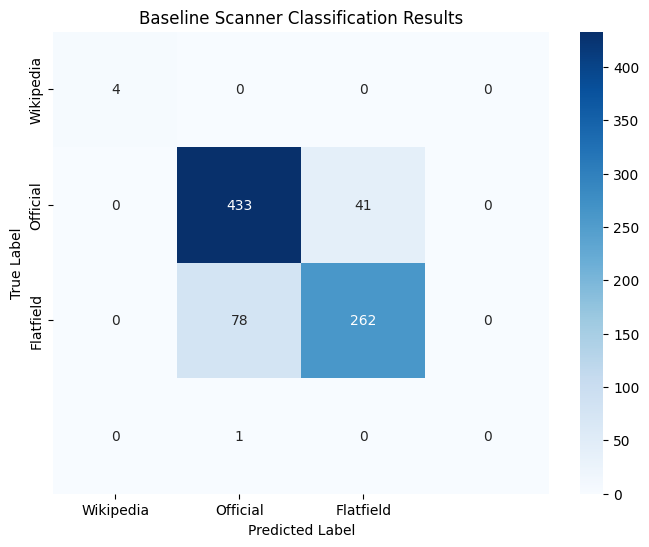

In [6]:
# 5. Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Wikipedia', 'Official', 'Flatfield'],
            yticklabels=['Wikipedia', 'Official', 'Flatfield'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Baseline Scanner Classification Results')
plt.show()

Sample Testing & Visualizations

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# 1. Split data (80% Train, 20% Test) [cite: 38]
X_train, X_test, y_train, y_test = train_test_split(
    X_train_final, y_train_final, test_size=0.2, random_state=42
)

# 2. Normalize features for SVM
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Define and Train Random Forest [cite: 28, 29]
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
print("✅ rf_model is now trained and defined.")

# 4. Define and Train SVM with RBF Kernel [cite: 32, 33]
svm_model = SVC(kernel='rbf', probability=True)
svm_model.fit(X_train_scaled, y_train)
print("✅ svm_model is now trained and defined.")

✅ rf_model is now trained and defined.
✅ svm_model is now trained and defined.


In [8]:
import random

# Pick a random sample from the test set
sample_idx = random.randint(0, len(X_test) - 1)
test_sample = X_test[sample_idx].reshape(1, -1)
test_sample_scaled = X_test_scaled[sample_idx].reshape(1, -1)

# Map numeric IDs to scanner names from your document [cite: 53, 61]
class_map = {
    0: "Canon120-1", 1: "Canon120-2", 2: "Canon220",
    3: "Canon9000-1", 4: "Canon9000-2", 5: "EpsonV370-1",
    6: "EpsonV370-2", 7: "EpsonV39-1", 8: "EpsonV39-2",
    9: "EpsonV550", 10: "HP"
}

# Get Predictions
rf_p = rf_model.predict(test_sample)[0]
svm_p = svm_model.predict(test_sample_scaled)[0]
true_l = y_test[sample_idx]

# Final Output for Report [cite: 66, 70, 74]
print(f"True Label: {class_map[true_l]}")
print(f"RF Predict: {class_map[rf_p]}")
print(f"SVM Predict: {class_map[svm_p]}")
print("-" * 30)
print(f"True: {class_map[true_l]} | RF: {class_map[rf_p]} | SVM: {class_map[svm_p]}")

True Label: Canon220
RF Predict: Canon120-2
SVM Predict: Canon120-2
------------------------------
True: Canon220 | RF: Canon120-2 | SVM: Canon120-2


Repository Export

In [10]:
import os

# Create the folder structure to match your repository
folders = ['features', 'models', 'result']
for folder in folders:
    if not os.path.exists(folder):
        os.makedirs(folder)
        print(f"✅ Created folder: {folder}")

✅ Created folder: features
✅ Created folder: models
✅ Created folder: result


In [11]:
import numpy as np
import joblib

# 1. Save features
np.save('features/X_features.npy', X_train_final)
np.save('features/y_labels.npy', y_train_final)

# 2. Save trained models
joblib.dump(rf_model, 'models/random_forest_baseline.pkl')
joblib.dump(svm_model, 'models/svm_baseline.pkl')
# Note: Ensure you run your training code first so rf_model and svm_model are defined!

print("✅ All files saved to repository folders.")

✅ All files saved to repository folders.


✅ Result image saved.


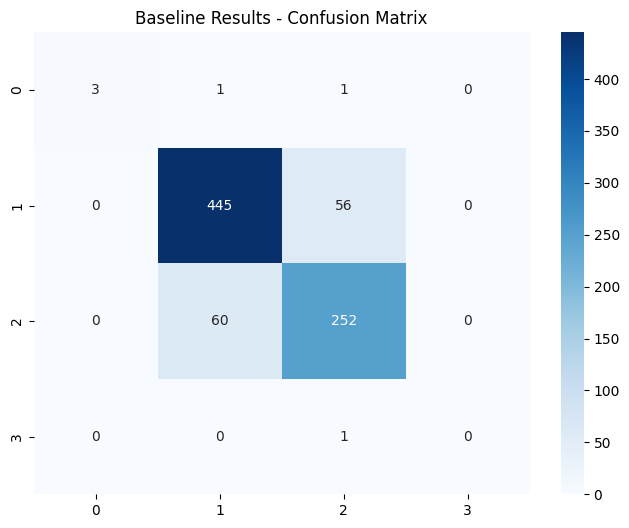

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# [cite_start]Generate the confusion matrix [cite: 46]
cm = confusion_matrix(y_test, rf_model.predict(X_test))
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Baseline Results - Confusion Matrix')

# Save to the result folder
plt.savefig('result/confusion_matrix.png')
print("✅ Result image saved.")